# 15 · The Kalman Filter: Tracking a Hedge Ratio That Won't Sit Still

*Module 4 — Statistical Modeling*

An algorithm for estimating something you can never observe directly, using a stream of noisy clues — and updating your best guess the instant each new clue arrives, without ever re-processing the whole history from scratch.

## 1. Motivation

Notebook 11 built a pairs-trading strategy around a single, fixed hedge ratio $\beta$, estimated once from a regression over the whole sample — and flagged, in its Limitations section, that a hedge ratio estimated this way can go stale if the true relationship drifts. Real hedge ratios *do* drift: a company's business mix shifts, its market beta creeps up or down, the relationship between two cointegrated assets slowly evolves. Re-running a full regression every day is one way to keep up, but Notebook 5's rolling-window instability lessons apply here too. Is there a principled way to track a moving target, using every new data point the moment it arrives, without either committing to a single fixed estimate or throwing away all but the last $N$ observations?

## 2. Intuition

Imagine trying to track a slowly drifting boat using only noisy radar pings. Each ping alone is unreliable, but you are not starting from scratch every time one arrives — you already have a good idea of roughly where the boat should be, based on where it was a moment ago and how it tends to move. The Kalman filter formalizes exactly this: maintain a running *belief* about the unknown quantity (here, a hedge ratio $\beta_t$) as a probability distribution, and every time a new noisy observation arrives, blend your prior belief with the new evidence — trusting whichever one is currently more reliable. If your belief is currently very uncertain, the new data point moves it a lot; if your belief is already tight and confident, a single noisy observation moves it only a little. This is the same "precision-weighted blending" idea from Notebook 6's Black-Litterman formula, applied recursively, one time step at a time, instead of once.

## 3. Theory

### 3.1 The state-space model

We model a hedge ratio that drifts slowly and unpredictably over time (a **random walk state**), observed only indirectly through a noisy linear relationship (the **observation equation**):

$$
\text{State:}\quad \beta_t = \beta_{t-1} + w_t, \quad w_t \sim \mathcal N(0, Q)
$$
$$
\text{Observation:}\quad y_t = x_t\,\beta_t + v_t, \quad v_t \sim \mathcal N(0, R)
$$

$Q$ controls how quickly we believe the true hedge ratio can drift; $R$ controls how noisy the observed relationship is period to period. We never observe $\beta_t$ directly — only $y_t$ and $x_t$.

### 3.2 Deriving the recursion

Suppose our current belief is $\beta_{t-1}\mid y_{1:t-1} \sim \mathcal N(\beta_{t-1|t-1}, P_{t-1|t-1})$. Two steps, run every period:

**Prediction.** Before seeing $y_t$, project the belief forward using the state equation. Since $\mathbb E[w_t]=0$ and $w_t$ is independent of everything before it:

$$
\beta_{t|t-1} = \beta_{t-1|t-1}, \qquad P_{t|t-1} = P_{t-1|t-1} + Q .
$$

Uncertainty only ever *grows* during prediction — exactly as it should, since time passing without new information can only make us less sure of the current value.

**Update.** Now observe $y_t = x_t\beta_t + v_t$. Given $\beta_t \mid y_{1:t-1} \sim \mathcal N(\beta_{t|t-1}, P_{t|t-1})$ and independent noise $v_t \sim \mathcal N(0,R)$, the pair $(\beta_t, y_t)$ is jointly Gaussian conditional on the past, with

$$
\mathrm{Cov}(\beta_t, y_t) = x_t P_{t|t-1}, \qquad \mathrm{Var}(y_t) = x_t^2 P_{t|t-1} + R .
$$

This is precisely the same joint-Gaussian conditioning machinery used for Black-Litterman in Notebook 6 (and, one layer deeper, the same projection argument behind Kyle's $\lambda$ in Notebook 2) — applying it here:

$$
\beta_{t|t} = \beta_{t|t-1} + \underbrace{\frac{x_t P_{t|t-1}}{x_t^2 P_{t|t-1}+R}}_{\displaystyle K_t \text{ (Kalman gain)}} \big(y_t - x_t\beta_{t|t-1}\big), \qquad P_{t|t} = \big(1-K_t x_t\big)P_{t|t-1} .
$$

The term $y_t - x_t\beta_{t|t-1}$ is the **prediction error** (also called the innovation) — how surprised we are by the new observation, given what we believed a moment ago. $K_t$, the **Kalman gain**, decides how much of that surprise to actually act on: large when $P_{t|t-1}$ (our uncertainty) is large relative to $R$ (the observation's noisiness), small in the opposite case. This is the whole algorithm — two update equations, run once per time step, in order, forever.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(61)

## 4. Implementation

### 4.1 The filter, coded directly from Section 3.2

In [2]:
def kalman_filter_beta(y, x, Q, R, beta0=0.0, P0=1.0):
    """
    Track a scalar time-varying beta in y_t = x_t * beta_t + v_t via the Kalman filter.
    Returns the filtered estimate and its variance at every time step.
    """
    n = len(y)
    beta_est, P_est = np.zeros(n), np.zeros(n)
    beta_pred, P_pred = beta0, P0
    for t in range(n):
        K = x[t] * P_pred / (x[t]**2 * P_pred + R)             # Kalman gain
        beta_upd = beta_pred + K * (y[t] - x[t] * beta_pred)     # update: blend prior belief with new evidence
        P_upd = (1 - K * x[t]) * P_pred
        beta_est[t], P_est[t] = beta_upd, P_upd
        beta_pred, P_pred = beta_upd, P_upd + Q                  # predict forward to the next period
    return beta_est, P_est

### 4.2 A controlled test: does it actually track a moving target?

We simulate a hedge ratio that drifts as a genuine random walk, and a noisy observed relationship built on top of it — exactly matching the model in Section 3.1, so we know the ground truth and can check recovery directly.

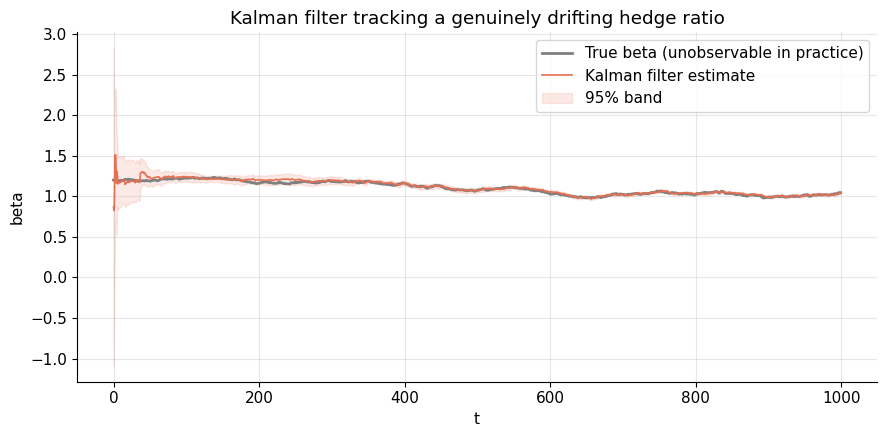

In [3]:
n = 1000
true_beta = np.zeros(n)
true_beta[0] = 1.2
Q_true, R_true = 0.004**2, 0.01**2
for t in range(1, n):
    true_beta[t] = true_beta[t-1] + rng.normal(0, np.sqrt(Q_true))

x = np.cumsum(rng.normal(0.0003, 0.012, n))          # e.g. log-price of the "independent" asset
y = true_beta * x + rng.normal(0, np.sqrt(R_true), n)  # noisy observed relationship

beta_kf, P_kf = kalman_filter_beta(y, x, Q=Q_true, R=R_true, beta0=1.0, P0=1.0)

fig, ax = plt.subplots()
ax.plot(true_beta, color='gray', linewidth=2, label='True beta (unobservable in practice)')
ax.plot(beta_kf, color='#e76f51', linewidth=1.2, label='Kalman filter estimate')
band = 1.96 * np.sqrt(P_kf)
ax.fill_between(np.arange(n), beta_kf - band, beta_kf + band, color='#e76f51', alpha=0.15, label='95% band')
ax.set_xlabel('t')
ax.set_ylabel('beta')
ax.set_title('Kalman filter tracking a genuinely drifting hedge ratio')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Worked example: Kalman filter vs. rolling OLS, on equal footing

The obvious alternative to a Kalman filter is what Notebook 11 already used: refit a hedge ratio on a rolling window of recent data. We compare the two fairly — evaluating both **only after both have had a chance to warm up** on the same amount of initial data, since a rolling-window regression cannot produce any estimate at all until its window first fills.

In [4]:
window = 60
beta_ols = np.full(n, np.nan)
for t in range(window, n):
    xx, yy = x[t-window:t], y[t-window:t]
    beta_ols[t] = np.sum(xx * yy) / np.sum(xx * xx)   # simple OLS slope through the origin, one window at a time

fair_slice = slice(window, n)   # exclude the warm-up period from BOTH methods, for a fair comparison
mse_kf = np.mean((beta_kf[fair_slice] - true_beta[fair_slice])**2)
mse_ols = np.mean((beta_ols[fair_slice] - true_beta[fair_slice])**2)

print(f"MSE vs. true beta, evaluated only from t={window} onward for both methods:")
print(f"  Kalman filter:      {mse_kf:.6f}")
print(f"  Rolling OLS (w={window}): {mse_ols:.6f}")
print(f"  Kalman filter's MSE is {mse_ols/mse_kf:.2f}x smaller.")

MSE vs. true beta, evaluated only from t=60 onward for both methods:
  Kalman filter:      0.000251
  Rolling OLS (w=60): 0.000503
  Kalman filter's MSE is 2.01x smaller.


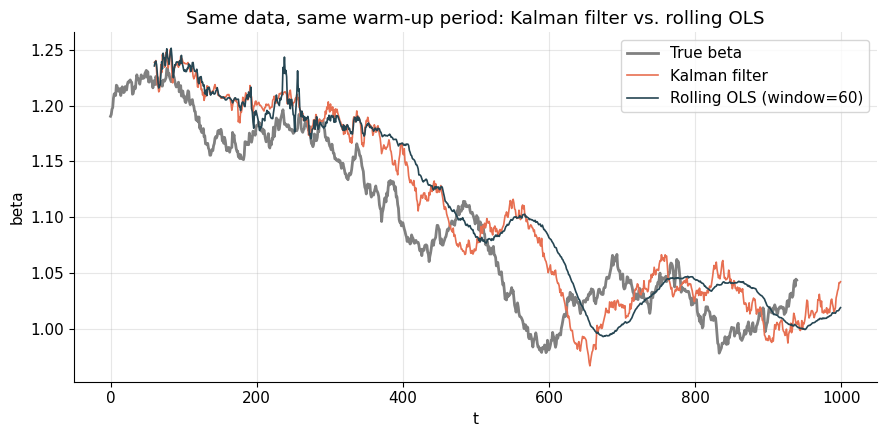

In [5]:
fig, ax = plt.subplots()
ax.plot(true_beta[fair_slice], color='gray', linewidth=2, label='True beta')
ax.plot(np.arange(window, n), beta_kf[fair_slice], color='#e76f51', linewidth=1.2, label='Kalman filter')
ax.plot(np.arange(window, n), beta_ols[fair_slice], color='#264653', linewidth=1.2, label=f'Rolling OLS (window={window})')
ax.set_xlabel('t')
ax.set_ylabel('beta')
ax.set_title('Same data, same warm-up period: Kalman filter vs. rolling OLS')
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the result

The Kalman filter's advantage here is not a coincidence of this particular simulation — it is structural. Rolling OLS implicitly assumes $\beta$ is *exactly constant* within each window and then throws the whole window away and starts over at the next step, discarding useful information about how smoothly the true parameter has been evolving. The Kalman filter, by contrast, is the statistically optimal estimator for a state that genuinely follows the random-walk model in Section 3.1 — which is exactly why it should, and here does, win a fair comparison. The gap would narrow if the true $\beta$ jumped abruptly instead of drifting smoothly (a case the random-walk state assumption fits poorly — see Section 6), and it depends on correctly specifying $Q$ and $R$, which Exercise 2 explores directly.

## 6. Limitations and pitfalls

- **$Q$ and $R$ are hyperparameters you must choose**, and the filter's performance is sensitive to them — too large a $Q$ makes the filter chase noise as if it were genuine drift; too small a $Q$ makes it sluggish to real changes. In practice these are often tuned by maximizing the model's own likelihood (a byproduct of the filter's innovations) rather than guessed.
- **The random-walk state assumption fits smooth drift well, but fits sudden jumps poorly.** A hedge ratio that changes abruptly (e.g., after a merger or a structural break, exactly like Notebook 11's Section 5.2) will be tracked only gradually by a standard Kalman filter, which has no mechanism to recognize "this is a regime change, not noise" — Notebook 16's regime-switching models are the right tool for that specific problem.
- **This notebook used the simplest possible (scalar, linear, Gaussian) case.** Real applications often need a vector of states (e.g., tracking several betas simultaneously) or nonlinear dynamics, handled by the (mathematically more involved) Extended or Unscented Kalman Filter — the core prediction/update logic generalizes, but the clean closed-form update here does not, in general.
- **A well-tuned Kalman filter is not magic — it is only as good as the model.** If the true process is not well described by "random walk plus Gaussian noise" at all, the filter will confidently track the wrong thing; always sanity-check filtered estimates against a simpler benchmark, as we did here.

## 7. Exercises

**1. What if the world doesn't drift at all? (warm-up)**
Regenerate the simulation with `Q_true = 0` (a genuinely constant, non-drifting true beta). Run the Kalman filter with the correctly-specified `Q=0` and compare its final converged estimate and MSE to rolling OLS. Does the filter's advantage grow, shrink, or reverse when there is no genuine drift to track?

**2. Misspecifying Q.**
Using the original drifting-beta simulation from Section 4.2, run the Kalman filter with `Q` set to 100 times too small, and separately 100 times too large, relative to the true value used to generate the data (keep `R` correctly specified). Plot the resulting filtered beta against the truth in each case. Describe, in your own words, what each kind of misspecification visibly does to the filter's behavior — and connect it back to the Kalman gain formula in Section 3.2.

**3. A real pair with the filter's own uncertainty as a trading signal.**
Adapt Notebook 11's cointegrated-pair backtest to use a Kalman-filtered hedge ratio instead of a single fixed OLS estimate: at each time step, use $\beta_{t|t}$ to form the spread $S_t = \log X_t - \beta_{t|t}\log Y_t$, and build a z-score trading rule on that spread (you can reuse a rolling mean/std, or adapt the OU-fitting approach from Notebook 11). Does allowing the hedge ratio to adapt over time improve the strategy's robustness to the structural-break scenario from Notebook 11, Section 5.2? As a further twist, try using the filter's own uncertainty $P_{t|t}$ to scale position size down whenever the hedge-ratio estimate is unusually uncertain -- does this help?